In [2]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [9]:
train_dataset = datasets.ImageFolder(root="../data/train", transform=transform)
test_dataset = datasets.ImageFolder(root="../data/test", transform=transform)

In [10]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [11]:
print("Classes:", train_dataset.classes)
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Classes: ['ai_generated', 'real']
Train size: 795
Test size: 200


In [12]:
import torch.nn as nn
from torchvision import models

# Load pretrained model
model = models.resnet18(pretrained=True)

# Freeze base layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)  # 2 classes

# Move to device
model = model.to(device)

print("Model ready")

c:\Users\Om Mishra\.conda\envs\cv_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Om Mishra\.conda\envs\cv_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Om Mishra/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:12<00:00, 3.76MB/s]


Model ready


In [14]:
import torch.optim as optim

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer (only train final layer)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print("Loss and optimizer ready")

Loss and optimizer ready


In [15]:
EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {running_loss:.4f}")

Epoch [1/5], Loss: 11.9272
Epoch [2/5], Loss: 7.7245
Epoch [3/5], Loss: 5.8185
Epoch [4/5], Loss: 4.7882
Epoch [5/5], Loss: 3.9497


In [16]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 94.00%


In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())



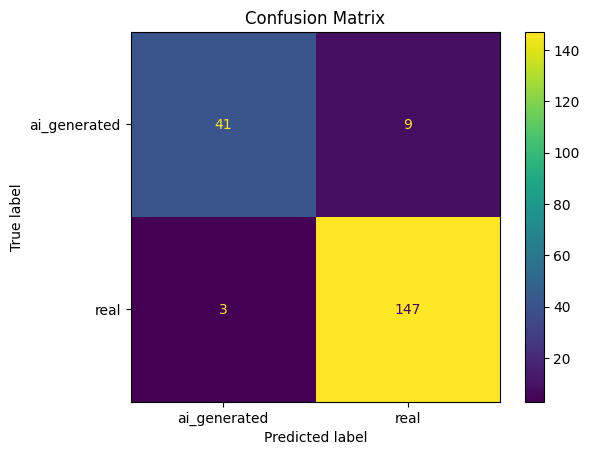

In [20]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
disp.plot()

plt.title("Confusion Matrix")
plt.show()